# <font color=#F90499>**Modelo Hackathonnn**</font>
***

## <font color=#05C0F3>**Introduccion al problema**</font>

### **Sector del negocio**

Atención al cliente / Marketing / Operaciones — empresas que recopilan opiniones de clientes (reseñas, comentarios en redes sociales, encuestas de satisfacción) y quieren entender rápidamente si el sentimiento es positivo, neutro o negativo.
***

### **Descripción del proyecto**

Crear una API simple que recibe textos (comentarios, reseñas o tweets), aplica un modelo de Data Science para clasificar el sentimiento (Atrasado / Puntual → en este caso: Positivo / Neutro / Negativo o binario Positivo / Negativo) y devuelve el resultado en formato JSON, permitiendo que las aplicaciones consuman esta predicción automáticamente.
***

### **Necesidad del cliente (explicación no técnica)**

Un cliente (empresa) recibe muchos comentarios y no puede leerlos todos manualmente. Quiere:

1. saber rápidamente si los clientes se están quejando o elogiando;

2. priorizar respuestas a comentarios negativos;

3. medir la satisfacción a lo largo del tiempo.

Este proyecto ofrece una solución automática para clasificar mensajes y generar información accionable.
***

### **Validación de mercado**

Analizar si el sentimiento es útil para:

- acelerar la atención al cliente (identificar urgencias);

- monitorear campañas de marketing;

- comparar la imagen de la marca a lo largo del tiempo.

Incluso una solución simple (modelo básico) tiene valor: las pequeñas y medianas empresas utilizan herramientas similares para entender los feedbacks sin un equipo dedicado.
***

### **Expectativa para este hackathon**

**Público:** estudiantes sin experiencia profesional en el área de tecnología, que estudiaron Back-end (Java, Spring, REST, persistencia) y Data Science (Python, Pandas, scikit-learn, notebooks).

**Objetivo:** entregar un MVP funcional que demuestre la integración entre DS y Back-end: un notebook con el modelo + una API que carga ese modelo y responde a las peticiones.

**Alcance recomendado:** clasificación binaria (Positivo / Negativo) o ternaria (Positivo / Neutro / Negativo) con un modelo simple — por ejemplo, usar TF-IDF (una técnica que transforma el texto en números, mostrando qué palabras son más importantes) junto con Regresión Logística (un modelo de aprendizaje automático que aprende a diferenciar sentimientos).
***

### **Entregables deseados**

Notebook (Jupyter/Colab) del equipo de Data Science que contenga:

1. Exploración y limpieza de los datos (EDA);

2. Transformación de los textos en números con TF-IDF;

3. Entrenamiento de modelo supervisado (ej.: Logistic Regression, Naive Bayes);

4. Métricas de desempeño (Accuracy, Precision, Recall, F1-score);

5. Serialización del modelo (joblib/pickle).
***

### **Documentación mínima (README):**

- Cómo ejecutar el modelo.

- Dependencias y versiones de las herramientas.

- Demonstración funcional (Presentación corta).

- Explicar cómo el modelo llega a la predicción.
***

### **Funcionalidades exigidas (MVP)**

1. El servicio debe exponer un endpoint que devuelve la clasificación del sentimiento y la probabilidad asociada a esa clasificación. Ejemplo: POST /sentiment — acepta JSON con campo text y devuelve: `{ "prevision": "Positivo", "probabilidad": 0.87 }`

2. Modelo entrenado y cargable: el back-end debe poder usar el modelo (cargando archivo) o hacer una petición a un microservicio DS que implemente la predicción.

3. Validación de input: verificar si text existe y tiene longitud mínima; devolver error amigable en caso contrario.

4. Respuesta clara: label (+ probabilidad en 0–1) y mensaje de error cuando sea aplicable.

5. Ejemplos de uso: Postman/cURL con 3 ejemplos reales (positivo, neutro, negativo).

6. README explicando cómo ejecutar (pasos simples) y cómo probar el endpoint.
***

### **Equipo de Data Science**

- Cada equipo debe elegir o armar su propio conjunto de datos de comentarios, reseñas o publicaciones que puedan utilizarse para el análisis de sentimientos (ej.: reviews públicos, tweets, evaluaciones de productos, etc.).

- usar Python, Pandas para leer/limpiar datos;

- crear un modelo simple (TF-IDF + LogisticRegression de scikit-learn);

- guardar el pipeline y el modelo con joblib.dump.

- Poner todo en un notebook bien comentado.
***

### **Contrato de integración (definido entre DS y BE)**


Recomendamos definir desde el principio el formato JSON de entrada y salida. Sigue un ejemplo:

{"text": "..."} →

{

"prevision":"Positivo",

"probabilidad":0.9

}
***

## <font color=#05C0F3>**Librerias**</font>

In [ ]:
!pip install langdetect

In [ ]:
import pandas as pd
# pd.set_option('display.max_colwidth', None)

import numpy as np

# Graficos
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_theme(style="whitegrid")

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Separador de datos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Modelo
from sklearn.linear_model import LogisticRegression

# Metricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluacion de metricas
from sklearn.metrics import classification_report

# Matriz de confusión
from sklearn.metrics import confusion_matrix

# Pipeline de prediccion
from sklearn.pipeline import Pipeline

# Serializacion
import joblib

#Detectar idiomas
from langdetect import detect

#Mezclar aleatoriamente
from sklearn.utils import shuffle

# Detectar idioma (mas rapida)
import fasttext

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


***

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

## <font color=#05C0F3>**Datos de reviews de amazon**</font>

In [ ]:
print('Train')
train_url = "https://huggingface.co/datasets/mteb/amazon_reviews_multi/resolve/main/es/train.jsonl"
train_df = pd.read_json(train_url, lines=True)
display(train_df)

print("\n" + "-" * 80 + "\n")

print('Test')
test_url = "https://huggingface.co/datasets/mteb/amazon_reviews_multi/resolve/main/es/test.jsonl"
test_df = pd.read_json(test_url, lines=True)
display(test_df)

print("\n" + "-" * 80 + "\n")

print('Validation')
val_url = "https://huggingface.co/datasets/mteb/amazon_reviews_multi/resolve/main/es/validation.jsonl"
val_df = pd.read_json(val_url, lines=True)
display(val_df)

Train


,id,text,label,label_text
0,es_0491108,television Nevir\n\nNada bueno se me fue ka pa...,0,0
1,es_0869872,Dinero tirado a la basura con esta compra\n\nH...,0,0
2,es_0811721,solo llega una unidad cuando te obligan a comp...,0,0
3,es_0359921,PRODUCTO NO RECIBIDO.\n\nNo entro en descalifi...,0,0
4,es_0068940,Devuelto\n\nLlega tarde y co la talla equivocada,0,0
...,...,...,...,...
199995,es_0715276,Tal y como se describe\n\nMando funciona perfe...,4,4
199996,es_0085190,Funciona perfectamente\n\nCompré la batería co...,4,4
199997,es_0484496,Buena calidad.\n\nBuena calidad. Satisfecha co...,4,4
199998,es_0930141,Recomendado\n\nPerfecto para el cumple de mi hijo,4,4



--------------------------------------------------------------------------------

Test


,id,text,label,label_text
0,es_0038754,no me llego\n\nno me llego el articulo me lo m...,0,0
1,es_0748979,amazon sigue sin cumplir en las entregas\n\nla...,0,0
2,es_0411746,ESTAFA EN EL ENVÍO\n\nEstoy muy decepcionado c...,0,0
3,es_0786686,Estafa de Amazon\n\nMi valoración no es sobre ...,0,0
4,es_0429700,No conseguí pasar de la portada en Kindle\n\nP...,0,0
...,...,...,...,...
4995,es_0685611,Perfectos para lo que sirven\n\nPara lo que cu...,4,4
4996,es_0638242,"Buen vendedor, rápido y fiable.\n\nMaterial mu...",4,4
4997,es_0760108,medallas con bonito grabado\n\nSe ve bien el g...,4,4
4998,es_0070806,timbre\n\nlo compré para mi bici pero finalmen...,4,4



--------------------------------------------------------------------------------

Validation


,id,text,label,label_text
0,es_0417480,"Mala compra\n\nMalisimo, muy grande demasiado ...",0,0
1,es_0180432,No lo he recibido\n\nNo he recibido el pedido ...,0,0
2,es_0144850,Que no aprieta bien en el manillar\n\nTengo qu...,0,0
3,es_0339629,Brocas de mantequilla\n\nUtilicé las brocas de...,0,0
4,es_0858362,No me gusta\n\nNo me gusta su olor a viejo y a...,0,0
...,...,...,...,...
4995,es_0179515,guadalupe\n\nMe ha encantado la cesta. Ha lleg...,4,4
4996,es_0894902,calidad precio\n\nDesempeña su función correct...,4,4
4997,es_0760496,Excelente\n\nMe ha encantado la diadema! Las f...,4,4
4998,es_0178380,"Genial\n\nA mi me gustan mucho las fundas TPU,...",4,4


In [ ]:
train_df = train_df[['text', 'label']]
test_df = test_df[['text', 'label']]
val_df = val_df[['text', 'label']]

## <font color=#05C0F3>**Analisis exploratorio de datos**</font>
***

### **Muestreo Aleatorio**

In [ ]:
print('Train')
display(train_df.head(10))

print("\n" + "-" * 80 + "\n")

print('Test')
display(test_df.head(10))

print("\n" + "-" * 80 + "\n")

print('Validation')
display(val_df.head(10))

Train


,text,label
0,television Nevir\n\nNada bueno se me fue ka pa...,0
1,Dinero tirado a la basura con esta compra\n\nH...,0
2,solo llega una unidad cuando te obligan a comp...,0
3,PRODUCTO NO RECIBIDO.\n\nNo entro en descalifi...,0
4,Devuelto\n\nLlega tarde y co la talla equivocada,0
5,Jamás me llegó\n\nJamás me llegó y el vendedor...,0
6,Horroroso!!!\n\nEl paraguas es de muy mala cal...,0
7,Poco funcional\n\nTuve que devolverla porque a...,0
8,No me llego\n\nEstoy esperando despues de prot...,0
9,"Mala calidad, defectuoso\n\nDefectuoso. En apa...",0



--------------------------------------------------------------------------------

Test


,text,label
0,no me llego\n\nno me llego el articulo me lo m...,0
1,amazon sigue sin cumplir en las entregas\n\nla...,0
2,ESTAFA EN EL ENVÍO\n\nEstoy muy decepcionado c...,0
3,Estafa de Amazon\n\nMi valoración no es sobre ...,0
4,No conseguí pasar de la portada en Kindle\n\nP...,0
5,Una verdadera pena\n\nCompre este teclado al v...,0
6,No compréis es un engaño\n\nSigue sin llegar d...,0
7,"No sirve para nada, pésimo producto\n\nNo sirv...",0
8,Pésimo trato del vendedor\n\nTodavía espero qu...,0
9,Pésima camara\n\nLa peor cámara que he tenido ...,0



--------------------------------------------------------------------------------

Validation


,text,label
0,"Mala compra\n\nMalisimo, muy grande demasiado ...",0
1,No lo he recibido\n\nNo he recibido el pedido ...,0
2,Que no aprieta bien en el manillar\n\nTengo qu...,0
3,Brocas de mantequilla\n\nUtilicé las brocas de...,0
4,No me gusta\n\nNo me gusta su olor a viejo y a...,0
5,"Bolas rotas\n\nHola, después de recoger el paq...",0
6,A parte de no poder elegir color...\n\nA parte...,0
7,Tapa pantalla\n\nMuy baja calidad de ahí si pr...,0
8,NO HE RECIBIDO EL PRODUCTO\n\nEl producto sale...,0
9,"Una patata.\n\nNo lo recomiendo, no se pega y ...",0


In [ ]:
print('Train')
display(train_df.tail(10))

print("\n" + "-" * 80 + "\n")

print('Test')
display(test_df.tail(10))

print("\n" + "-" * 80 + "\n")

print('Validation')
display(val_df.head(10))

Train


,text,label
199990,Julio\n\nMuy bueno y materiales muy bien. Faci...,4
199991,Muy cómodo!\n\nMi gato pesa 5 kg y entra perfe...,4
199992,"Muy bien\n\nMuy buen producto , juego muy dive...",4
199993,La droga +dura 2\n\nSi la primera parte me gus...,4
199994,Precio\n\nFuncional. Buena calidad/precio.,4
199995,Tal y como se describe\n\nMando funciona perfe...,4
199996,Funciona perfectamente\n\nCompré la batería co...,4
199997,Buena calidad.\n\nBuena calidad. Satisfecha co...,4
199998,Recomendado\n\nPerfecto para el cumple de mi hijo,4
199999,Preciosas\n\nSúper bien! Las brochas son buena...,4



--------------------------------------------------------------------------------

Test


,text,label
4990,buen producto\n\npedi una talla mas porque hab...,4
4991,Dinámico para bebes\n\nMuy didáctico y es tal ...,4
4992,Medias\n\nLas mejores medias que he tenido y l...,4
4993,Genial para no mojarse las manos\n\nEs genial ...,4
4994,producto barato y cumple con sus funciones\n\n...,4
4995,Perfectos para lo que sirven\n\nPara lo que cu...,4
4996,"Buen vendedor, rápido y fiable.\n\nMaterial mu...",4
4997,medallas con bonito grabado\n\nSe ve bien el g...,4
4998,timbre\n\nlo compré para mi bici pero finalmen...,4
4999,Auriculares sin cables de verdad\n\nPues este ...,4



--------------------------------------------------------------------------------

Validation


,text,label
0,"Mala compra\n\nMalisimo, muy grande demasiado ...",0
1,No lo he recibido\n\nNo he recibido el pedido ...,0
2,Que no aprieta bien en el manillar\n\nTengo qu...,0
3,Brocas de mantequilla\n\nUtilicé las brocas de...,0
4,No me gusta\n\nNo me gusta su olor a viejo y a...,0
5,"Bolas rotas\n\nHola, después de recoger el paq...",0
6,A parte de no poder elegir color...\n\nA parte...,0
7,Tapa pantalla\n\nMuy baja calidad de ahí si pr...,0
8,NO HE RECIBIDO EL PRODUCTO\n\nEl producto sale...,0
9,"Una patata.\n\nNo lo recomiendo, no se pega y ...",0


In [ ]:
print('Train')
display(train_df.sample(10))


Train


,text,label
38279,Material muy débil\n\nMaterial muy débil que p...,0
49865,"Problemas con la goma\n\nEn general está bien,...",1
104313,No esta mal\n\nEl producto no esta mal para el...,2
76358,No me convence al 100%\n\nEl producto cumple s...,1
192061,Esther Vera\n\nSon preciosos. Ideales para una...,4
54251,No es de calidad\n\nEsta bien acabada pero se ...,1
32330,Caja blanda y rota\n\nEl juego es el d siempre...,0
148550,Maravillosas y entretenidas\n\nMuy contenta. E...,3
66064,El tapón se cedió a los pocos días de uso y no...,1
151759,Muy buena relación calidad / precio\n\nCumpla ...,3


In [ ]:
print('Test')
display(test_df.sample(10))

Test


,text,label
957,Que se pague pero que sea el minimo eficaz\n\n...,0
3321,Buen producto.\n\nBuena relación calidad preci...,3
4503,Concha\n\nEra un regalo para mi hija y le ha e...,4
1829,Velas para oídos\n\nEl artículo recibido se aj...,1
3920,Cómo arnés de aprendizaje no sirve.\n\nEstá bi...,3
1837,Retraso\n\nQue el pedido no llegó en el tiempo...,1
1163,"NO ENFRIA\n\nLe pusimos hielo para probar, par...",1
1388,Enviado a Vecino si consentimiento\n\nProducto...,1
274,"No lo sé, no ha llegado\n\nTodavía no me ha ll...",0
2272,No ha llegado en tiempo referido\n\nEl product...,2


In [ ]:
print('Validation')
display(val_df.sample(10))

Validation


,text,label
4452,Genial\n\nHe descubierto a Diego Ojeda y estoy...,4
1200,Se despega la tela\n\nHay un problema grave. S...,1
477,No es la pulsera de Xiaomi\n\nLa pulsera no es...,0
3864,Guay!\n\nSalen muy bien! Divertido,3
818,Un vendedor nefasto\n\nUn desastre super peque...,0
2902,Maria\n\nViene sin la tumbona.Y en la caja si ...,2
3211,Buen producto\n\nMe gusta el precio y el produ...,3
4937,Fernando raya\n\nA simple vista muy bonita y b...,4
3999,"Ideal para bebés\n\nUn buen regalo para bebés,...",3
75,no sirve\n\nno tiene fuerza y no limpia,0


### **Verificación de Dimensiones y Tipos**

In [ ]:
print(f'Los datos de entrenamiento tienen {train_df.shape[0]} filas y {train_df.shape[1]} columnas.')
print(f'Los datos de prueba tienen {test_df.shape[0]} filas y {test_df.shape[1]} columnas.')
print(f'Los datos de validacion tienen {val_df.shape[0]} filas y {val_df.shape[1]} columnas.')

Los datos de entrenamiento tienen 200000 filas y 2 columnas.
Los datos de prueba tienen 5000 filas y 2 columnas.
Los datos de validacion tienen 5000 filas y 2 columnas.


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    200000 non-null  object
 1   label   200000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.1+ MB


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5000 non-null   object
 1   label   5000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 78.3+ KB


In [ ]:
val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5000 non-null   object
 1   label   5000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 78.3+ KB


### **Eliminando duplicados**

In [ ]:
display(train_df.shape)
display(test_df.shape)
display(val_df.shape)

(200000, 2)

(5000, 2)

(5000, 2)

In [ ]:
train_df = train_df.drop_duplicates()
test_df = test_df.drop_duplicates()
val_df = val_df.drop_duplicates()

In [ ]:
display(train_df.shape)
display(test_df.shape)
display(val_df.shape)

(199795, 2)

(5000, 2)

(5000, 2)

In [ ]:
200000 - 199795

205

Se eliminan *205* duplicados

### **Longitud de los textos**

In [ ]:
for i in [train_df, test_df, val_df]:
  display(i.describe())

,label
count,199795.000000
mean,1.999520
std,1.414167
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,4.000000


,label
count,5000.000000
mean,2.000000
std,1.414355
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,4.000000


,label
count,5000.000000
mean,2.000000
std,1.414355
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,4.000000


In [ ]:
for i in [train_df, test_df, val_df]:
  display(i['text'].describe())


,text
count,199795
unique,199726
top,Calidad precio correcto\n\nCalidad precio corr...
freq,3


,text
count,5000
unique,5000
top,Auriculares sin cables de verdad\n\nPues este ...
freq,1


,text
count,5000
unique,5000
top,Buena calidad\n\nEl artículo ha cumplido con l...
freq,1


In [ ]:
train_df['n_palabras'] = train_df['text'].str.split().str.len() # Separa todas las palabras del comentario y las cuenta
test_df['n_palabras'] = test_df['text'].str.split().str.len()
val_df['n_palabras'] = val_df['text'].str.split().str.len()

In [ ]:
train_df['n_palabras'].describe()

,n_palabras
count,199795.000000
mean,31.136100
std,24.820879
min,3.000000
25%,16.000000
50%,25.000000
75%,38.000000
max,566.000000


#### Longitud extrema: análisis más profundo de outliers

In [ ]:
train_df['n_palabras'].quantile([0.90, 0.95, 0.99])

,n_palabras
0.90,59.0
0.95,76.0
0.99,127.0


In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
train_df.loc[train_df['n_palabras'] > 127, 'text'].sample(1)

,text
95947,"Aprobado justito\n\nEs un set de 4 peonzas estilo Beyblade con los anillos metálicos para darles más consistencia. También incluye dos tiradores, uno de cuerda y otro con empuñadura y un estadio mini, que aunque parezca muy pequeño a mi hijo le ha encantado porque se lo puede llevar a cualquier sitio. Mi hijo tiene también el estadio original de Bey blade que es mucho más grande y le encanta, pero tiene la pega de que no se lo puede llevar a casa de los abuelos, y este pequeño sí. Evidentemente, la calidad deja mucho que desear. Si una sola Bey blade original cuesta prácticamente lo mismo que este set de cuatro peonzas, será por algo. A mi me compensa porque mi hijo se las lleva al colegio para jugar con sus amigos en el recreo, y cada dos o tres semanas pierde alguna pieza. Si sólo le comprara las originales no ganaría dinero para peonzas. Con éstas no me importa tanto que se le puedan perder. Además, las piezas son compatibles con las Bey blade originales y los tiradores también. Para mi, lo más importante es que el niño está encantado. Lleva como dos semanas con ellas y aún no se le ha roto nada. Si con el uso veo que hay problemas, editaré la opinión para añadirlo."


In [ ]:
train_df[['text', 'n_palabras']].query('n_palabras > 127').sample(10)

,text,n_palabras
49826,"No es lo que esperaba\n\nEstaba ilusionado por ver como funcionaba el aparato ya que los comentarios que ví de otros compradores eran muy buenos. Pero me ha decepcionado. Lo primero el tamaño, realmente no cabe nada que exceda de unos 12 cm. Y sobre todo que no sé muy bien como dicen que limpia muy bien... a mi no me limpia nada de lo que he probado. Todo lo que sumerjo en él sale exactamente igual de sucio que al principio. Y no será por hacerlo mal, ya que el método es super sencillo; introducir lo que queremos limpiar en el aparato sumergirlo en agua y listo... darle tiempo. Pero ni usando limpiadores ni repitiendo ciclos de 3 minutos ni nada. O mi aparato no funciona o no lo entiendo. En fin una decepción.",135
54774,"Muy poco práctica.\n\nLa compré por el precio, el diseño y el color. La entrega con el servicio de Correos Express ha sido una odisea. La lámpara se corresponde a la imagen, pero una vez colocada en el mueble que tengo en la parte superior del escritorio, veo que no consigo enfocarla bien porque la zona flexible del brazo es muy corta y la rotación es mínima, con lo que no se puede elegir la posición de la lámpara. Si lo llego a saber, no hubiera optado por esta compra. La mejor opción es sujetarla en el mismo tablero de la mesa, pero precisamente la compré de pinza porque no la quería poner en la superficie de la mesa porque a parte de quitar espacio, cuando está encendida quema y la tiene que usar mi hija. Otro gran inconveniente es el tema del cable, que al ser demasiado corto, no llega al enchufe y no parece tan fácil poder sustituirlo, aunque lo intentaré. La iluminación es buena. En fin, no me convence para nada y quizá la devuelva, a no ser que consiga hacerle algún apaño.",186
171495,"Me encanta - muy natural y no mancha\n\nDudé si comprar este producto o no, porque una vez compré un maquillaje para tapar varices y era muy artificial y quedaba fatal y manchaba y se veía que era maquillaje. Compré este porque me cuesta broncear las piernas en verano. Lo probé y me encanta. Es muy ligero y da un toque de bronceado que parece 100% natural. Hay que ponerlo con los manos y masajear bien para cubrir todo. En las fotos verás que lo puse en la pierna izquierda y la derecha no, para que se ve como queda. No cubre varices pero los disimula bastante. Vi fotos de una persona que le daba mala puntuación y se veía la bañera super sucio. Dijo que manchaba así al ponerlo. Diria que es imposible porque no mancha nada - se te pone la bañera sucia cuando lo quitas con agua y jabón, pero eso es normal, igual que cuando quitas un tinte de pelo en la ducha. Se va fácilmente de la bañera con la manguera de la ducha. También leí gente diciendo que mancha la ropa y no es cierto si lo aplicas bien. En la ultima foto, llevaba 4 horas con la ropa puesto después de haberlo aplicado y puedes ver que en el interior de mis pantalones cortos no hay producto ni residuo alguno. Hay que aplicar el producto y no vestirte por unos 10 minutos hasta que se haya absorbido totalmente - luego hagas lo que hagas no sale ni mancha. De hecho antes de aplicarla me había duchado y por la noche me fui a la cama sin ducharme y no manchó las sabanas y tenía las piernas perfectas de color igual que el día anterior. Se fue cuando me lo lavé con agua y jabón. Compré el color bronceado porque algo de color ya tengo. Llegó rápido y me parece producto fantástico. Por cierto en el mar tampoco sale. Va bien tambien para la cara y escote, brazos etc! Espero que haya sido de utilidad mi comentario.",343
33226,"Podría haber sido buena compra.\n\nLa verdad es que como teléfono no esta mal para el precio que tiene. Funciona de manera muy fluida, las fotos no están mal ni en exterior ni en interior, tiene una gran pantalla... Yo le habría metido los botones físicos, ya que estos le comen un trozo de pantalla y se nota bastante. Pero el problema es que mi terminal viene con un fallo que le hace inservible. La conexión wifi no funciona correct

In [ ]:
pd.set_option('display.max_colwidth', 50)

### **Verificar la distribución de la columna objetivo (Sentimiento)**

In [ ]:
train_df['label'].value_counts()

,count
label,
1,39986
0,39967
2,39960
4,39942
3,39940


In [ ]:
train_df['label'].value_counts(normalize=True)

,proportion
label,
1,0.200135
0,0.200040
2,0.200005
4,0.199915
3,0.199905


In [ ]:
train_df.sample(10)

,text,label,n_palabras
153877,Justo lo que buscaba a un precio muy asequible...,3,55
74085,"Calidad normal\n\nMe ha dado algunos fallos, h...",1,18
196703,Muy buena relación calidad precio\n\nMe llegó ...,4,73
184785,Los cuchillos definitivos\n\nBueno lo de estos...,4,26
199363,"Recomendable seguro\n\nMuy buen producto, tal ...",4,23
80737,Para tener entre algodones\n\nAl cabo de u. Ti...,2,23
40433,"Bien, pero el cargador no vale\n\nLa tablet fu...",1,27
129135,Libro muy entretenido para los niños\n\nEste l...,3,40
188905,Buena compra\n\nCalidad precio perfecto tamaño...,4,7
150771,"Bueno en general\n\nCumple, un poco grande, lo...",3,10


In [ ]:
def map_sentiment(stars):
    if stars <= 2:
        return "Negativo"
    elif stars == 3:
        return "Neutro"
    else:
        return "Positivo"

train_df["label"] = train_df["label"].apply(map_sentiment)
test_df["label"] = test_df["label"].apply(map_sentiment)
val_df["label"] = val_df["label"].apply(map_sentiment)

### **Graficos**

In [ ]:
sns.axes_style()

{'axes.facecolor': 'white',
 'axes.edgecolor': '.8',
 'axes.grid': True,
 'axes.axisbelow': True,
 'axes.labelcolor': '.15',
 'figure.facecolor': 'white',
 'grid.color': '.8',
 'grid.linestyle': '-',
 'text.color': '.15',
 'xtick.color': '.15',
 'ytick.color': '.15',
 'xtick.direction': 'out',
 'ytick.direction': 'out',
 'lines.solid_capstyle': <CapStyle.round: 'round'>,
 'patch.edgecolor': 'w',
 'patch.force_edgecolor': True,
 'image.cmap': 'rocket',
 'font.family': ['sans-serif'],
 'font.sans-serif': ['Arial',
  'DejaVu Sans',
  'Liberation Sans',
  'Bitstream Vera Sans',
  'sans-serif'],
 'xtick.bottom': False,
 'xtick.top': False,
 'ytick.left': False,
 'ytick.right': False,
 'axes.spines.left': True,
 'axes.spines.bottom': True,
 'axes.spines.right': True,
 'axes.spines.top': True}

In [ ]:
sns.set_theme(
    style="darkgrid",
    font_scale=1.1
)

### Colores

In [ ]:
color_primario   = "#05C0F3"  # Azul
color_secundario = "#F90499"  # Magenta
color_terciario  = "#2ECC71"  # Verde
color_cuarto     = "#F1C40F"  # Amarillo
color_quinto     = "#E74C3C"  # Rojo

#### Histograma

¿Cómo es la distribución del tamaño de los textos (reviews) que usaremos para entrenar el modelo de sentimiento?

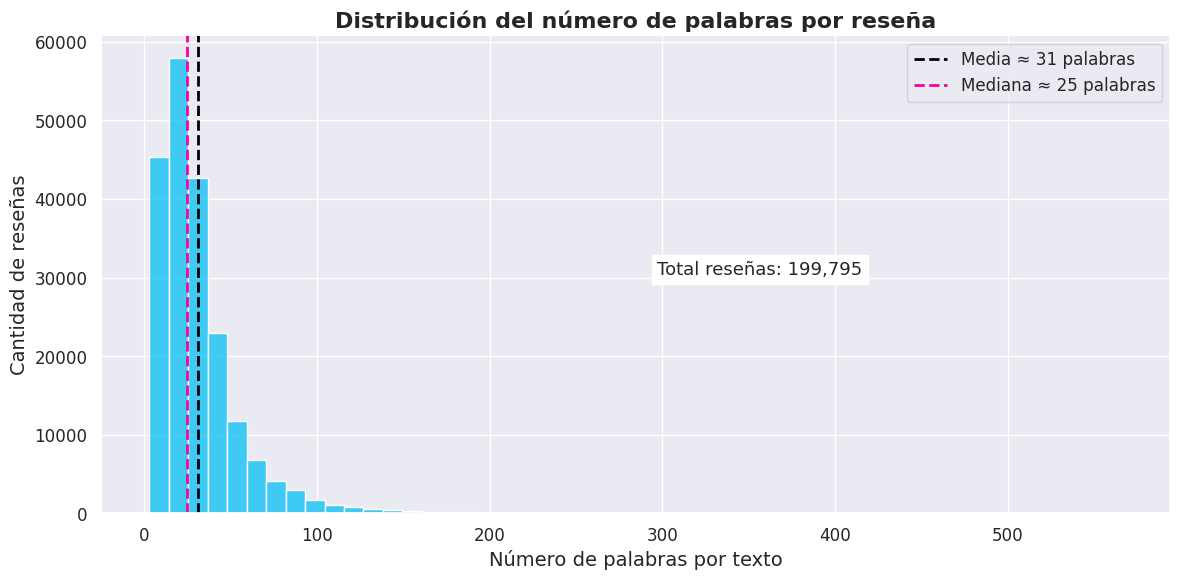

In [ ]:
def distribucion_numero_palabras_por_reseña():
  plt.figure(figsize=(12, 6))

  sns.histplot(
      train_df['n_palabras'],
      bins = 50,
      color = color_primario
      )

  plt.title(
      "Distribución del número de palabras por reseña",
      fontsize = 16,
      fontweight = "bold"
  )

  plt.xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  plt.ylabel(
      "Cantidad de reseñas",
      fontsize = 14
  )

  media = train_df['n_palabras'].mean()
  plt.axvline( # muestra la linea punteada que señala el promedio
      media,
      color = 'black',
      linestyle = "--",
      linewidth = 2,
      label = f"Media ≈ {media:.0f} palabras"
  )
  # Línea de referencia: mediana
  mediana = train_df['n_palabras'].median()
  plt.axvline(
      mediana,
      color=color_secundario,
      linestyle="--",
      linewidth=2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )

  plt.text(
      0.50 * plt.xlim()[1],
      0.50 * plt.ylim()[1],
      f"Total reseñas: {len(train_df):,}",
      fontsize=13,
      bbox=dict(facecolor="white")
  )

  plt.legend() # Muestra la leyenda
  plt.tight_layout()
  plt.show()

distribucion_numero_palabras_por_reseña()

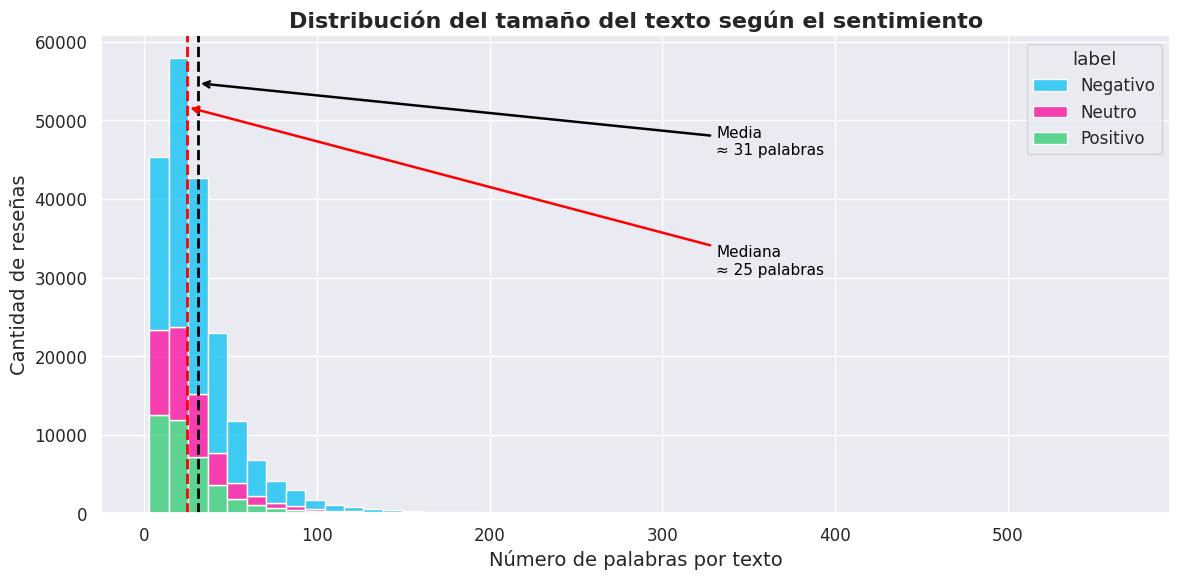

In [ ]:
def distribucion_numero_palabras_por_reseña_por_sentimiento():
  fig, ax = plt.subplots(figsize=(12,6))

  sns.histplot(
      data = train_df,
      x = 'n_palabras',
      hue = 'label',
      palette = [color_primario, color_secundario, color_terciario],
      bins=50,
      multiple = "stack"
      )

  ax.set_title(
      "Distribución del tamaño del texto según el sentimiento",
      fontsize = 16,
      fontweight = "bold"
  )

  ax.set_xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  ax.set_ylabel(
      "Cantidad de reseñas",
      fontsize = 14
  )

  media = train_df['n_palabras'].mean()
  ax.axvline( # muestra la linea punteada que señala el promedio
      media,
      color = 'black',
      linestyle = "--",
      linewidth = 2,
      label = f"Media ≈ {media:.0f} palabras"
  )
  # Línea de referencia: mediana
  mediana = train_df['n_palabras'].median()
  ax.axvline(
      mediana,
      color = 'red',
      linestyle = "--",
      linewidth = 2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )

  ax.annotate(
      f"Media\n≈ {media:.0f} palabras",
      xy = (media, ax.get_ylim()[1] * 0.9),      # apunta a la línea
      xytext = (media + 300, ax.get_ylim()[1] * 0.75),
      arrowprops = dict(
            arrowstyle = "->",
            color = 'black',
            linewidth = 1.8
            ),
      fontsize = 11,
      color = 'black'
      )

  texto_moda = ('Mediana')
  ax.annotate(
      f"Mediana\n≈ {mediana:.0f} palabras",
        xy = (mediana, ax.get_ylim()[1] * 0.85),      # apunta a la línea
      xytext = (media + 300, ax.get_ylim()[1] * 0.50),
      arrowprops = dict(
            arrowstyle = "->",
            color = 'red',
            linewidth = 1.8
            ),
      fontsize = 11,
      color = 'black'
      )

  plt.tight_layout()
  plt.show()

distribucion_numero_palabras_por_reseña_por_sentimiento()

#### Boxplot

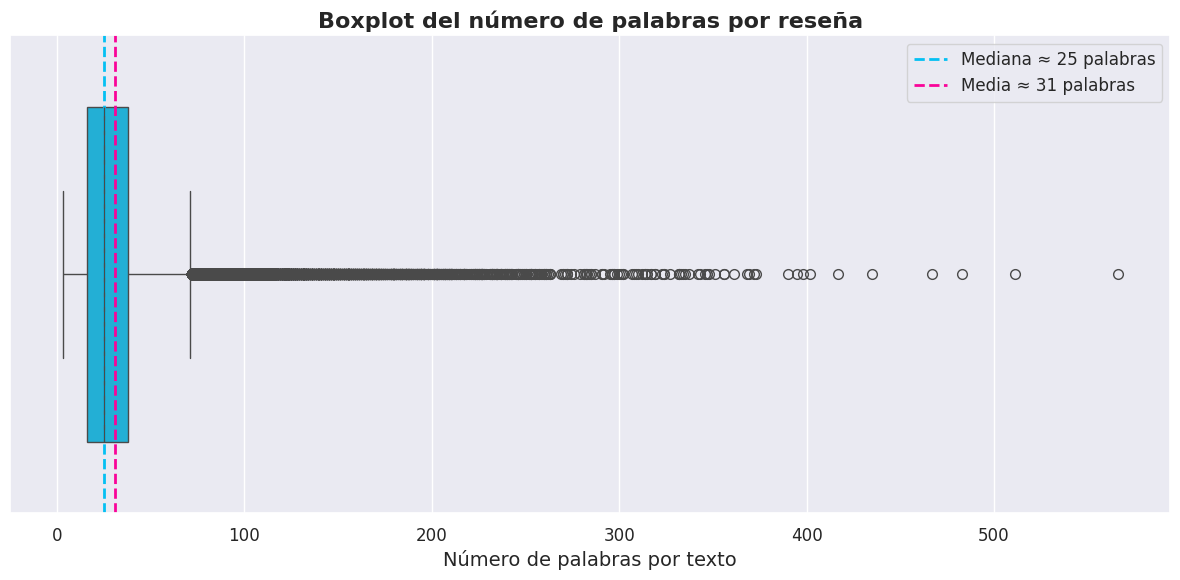

In [ ]:
def boxplot_numero_palabras_por_reseña():
  plt.figure(figsize=(12, 6))

  sns.boxplot(
      x = train_df['n_palabras'],
      color = color_primario,
      width = 0.7, # Tamaño del boxplot
      fliersize = 7, # Tamaño de los puntos atípicos
  )

  plt.title(
      "Boxplot del número de palabras por reseña",
      fontsize = 16,
      fontweight = "bold"
  )

  plt.xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  # Línea de referencia: mediana
  mediana = train_df['n_palabras'].median()
  plt.axvline(
      mediana,
      color=color_primario,
      linestyle="--",
      linewidth=2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )
  # Línea de referencia: media
  media = train_df['n_palabras'].mean()
  plt.axvline(
      media,
      color=color_secundario,
      linestyle="--",
      linewidth=2,
      label=f"Media ≈ {media:.0f} palabras"
  )


  plt.legend()
  plt.tight_layout()
  plt.show()

boxplot_numero_palabras_por_reseña()

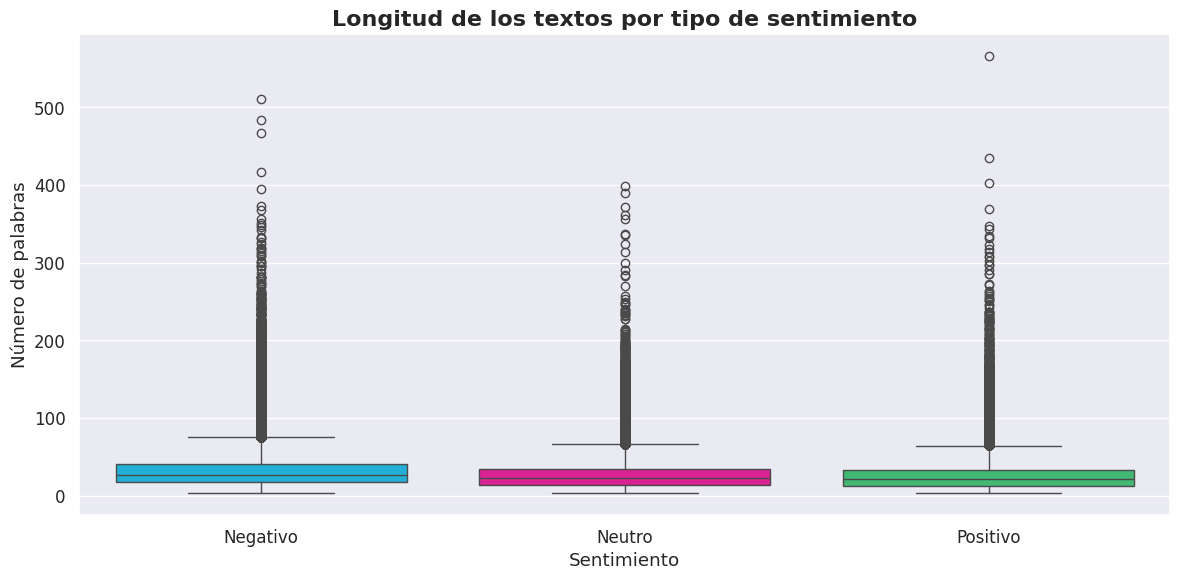

In [ ]:
def boxplot_numero_palabras_por_reseña_por_sentimiento():
  plt.figure(figsize=(12,6))

  sns.boxplot(
      data = train_df,
      x='label',
      y = 'n_palabras',
      hue = 'label',
      palette = [color_primario, color_secundario, color_terciario]
  )

  plt.title(
      "Longitud de los textos por tipo de sentimiento",
      fontsize=16,
      fontweight="bold"
      )

  plt.xlabel("Sentimiento")

  plt.ylabel("Número de palabras")

  plt.tight_layout()
  plt.show()

boxplot_numero_palabras_por_reseña_por_sentimiento()

### **Conclusion**

#### **Conclusiones sobre la calidad de los datos**

- El conjunto de datos presenta una estructura clara y consistente, compuesta principalmente por dos columnas relevantes para el modelado: el texto de la reseña y su respectiva etiqueta de sentimiento. Tras el proceso de limpieza, se eliminaron 205 registros duplicados, una cantidad mínima en comparación con el tamaño total del conjunto de entrenamiento (casi 200 000 observaciones), lo que confirma una alta calidad inicial de los datos y reduce el riesgo de sesgos por repetición durante el entrenamiento del modelo.

- No se detectaron valores nulos en las columnas analizadas, y los tipos de datos son adecuados para tareas de procesamiento de lenguaje natural, permitiendo un flujo de trabajo eficiente sin transformaciones estructurales adicionales.

#### **Conclusiones sobre la distribucion de las clases**

- Las etiquetas originales basadas en calificaciones fueron mapeadas a tres clases de sentimiento: Negativo, Neutro y Positivo, permitiendo construir un enfoque multiclase alineado con los objetivos del proyecto.

- Las estadísticas descriptivas muestran una distribución equilibrada y consistente entre los conjuntos de entrenamiento, prueba y validación, con valores medios cercanos y rangos idénticos, lo que indica una correcta separación de los datos y una adecuada representatividad entre los subconjuntos.

#### **Conclucion sobre la longitud de los textos**

- El análisis de la longitud de las reseñas evidencia que la mayoría de los textos son relativamente cortos, con una media aproximada de 31 palabras y una mediana cercana a 25 palabras. La distribución presenta una asimetría positiva, generada por un número reducido de reseñas extensas que alcanzan hasta 566 palabras.

- El histograma muestra que las reseñas con sentimiento negativo tienden a ser más largas, mientras que los textos neutros y positivos se concentran principalmente en rangos bajos de longitud. Este comportamiento es consistente con patrones habituales en plataformas de comercio electrónico, donde los usuarios insatisfechos suelen elaborar comentarios más detallados.

#### **Conclusión general del EDA**

- El análisis exploratorio confirma que el conjunto de datos es adecuado para entrenar un modelo de análisis de sentimiento multiclase como el propuesto en el MVP. La calidad de los datos, la distribución coherente de las etiquetas y la longitud moderada de los textos favorecen el uso de técnicas como TF-IDF combinadas con modelos supervisados clásicos como Regresión Logística.

- Si bien existen valores extremos en la longitud de los textos, estos no comprometen el entrenamiento del modelo y pueden ser gestionados en etapas posteriores mediante técnicas de truncamiento o normalización. En conjunto, el EDA proporciona una base sólida para la construcción del modelo y permite identificar oportunidades claras de mejora para iteraciones futuras.

## <font color=#05C0F3>**Limpieza de datos**</font>

### **Tratamiento de Valores Nulos e Inconsistencias**

#### Conteo de valores nulos

In [ ]:
display(train_df.isnull().sum())
display(test_df.isnull().sum())
display(val_df.isnull().sum())

,0
text,0
label,0
n_palabras,0
idioma_detectado,0
text_limpio,0


,0
text,0
label,0


,0
text,0
label,0


No hay valores nulos en ninguna columna

### **Limpieza y Normalización del Texto**

#### Eliminar reseñas en inglés

In [ ]:
def detectar_idioma(texto):
    try:
        return detect(texto) #Se usa la biblioteca langdetect
    except:
        return "desconocido"

In [ ]:
train_df.shape

(199795, 3)

In [ ]:
#Columna con el idioma de la reseña (El procesamiento tardará)
train_df['idioma_detectado'] = train_df['text'].apply(detectar_idioma)

In [ ]:
train_df

,text,label,n_palabras,idioma_detectado
0,television Nevir\n\nNada bueno se me fue ka pa...,Negativo,21,es
1,Dinero tirado a la basura con esta compra\n\nH...,Negativo,31,es
2,solo llega una unidad cuando te obligan a comp...,Negativo,32,es
3,PRODUCTO NO RECIBIDO.\n\nNo entro en descalifi...,Negativo,63,es
4,Devuelto\n\nLlega tarde y co la talla equivocada,Negativo,8,es
...,...,...,...,...
199995,Tal y como se describe\n\nMando funciona perfe...,Positivo,28,es
199996,Funciona perfectamente\n\nCompré la batería co...,Positivo,30,es
199997,Buena calidad.\n\nBuena calidad. Satisfecha co...,Positivo,8,es
199998,Recomendado\n\nPerfecto para el cumple de mi hijo,Positivo,8,es


In [ ]:
train_df_clean = train_df[train_df['idioma_detectado'] == 'es'].copy()

In [ ]:
filas_originales = len(train_df)
filas_limpias = len(train_df_clean)
print(f"Se eliminaron {filas_originales - filas_limpias} filas que no estaban en español")

Se eliminaron 0 filas que no estaban en español


In [ ]:
train_df = train_df_clean

In [ ]:
train_df.shape

(196428, 4)

#### Verificar la distribución de la columna objetivo (Sentimiento)

In [ ]:
train_df

,text,label,n_palabras,idioma_detectado
0,television Nevir\n\nNada bueno se me fue ka pa...,Negativo,21,es
1,Dinero tirado a la basura con esta compra\n\nH...,Negativo,31,es
2,solo llega una unidad cuando te obligan a comp...,Negativo,32,es
3,PRODUCTO NO RECIBIDO.\n\nNo entro en descalifi...,Negativo,63,es
4,Devuelto\n\nLlega tarde y co la talla equivocada,Negativo,8,es
...,...,...,...,...
199995,Tal y como se describe\n\nMando funciona perfe...,Positivo,28,es
199996,Funciona perfectamente\n\nCompré la batería co...,Positivo,30,es
199997,Buena calidad.\n\nBuena calidad. Satisfecha co...,Positivo,8,es
199998,Recomendado\n\nPerfecto para el cumple de mi hijo,Positivo,8,es


In [ ]:
for i in [train_df, test_df, val_df]:
  display(i['label'].value_counts())

,count
label,
Negativo,117521
Positivo,39488
Neutro,39419


,count
label,
Negativo,3000
Neutro,1000
Positivo,1000


,count
label,
Negativo,3000
Neutro,1000
Positivo,1000


In [ ]:
for i in [train_df, test_df, val_df]:
  print("\nEstadísticas de longitud antes del balanceo:")
  print(i.groupby('label')['n_palabras'].describe())


Estadísticas de longitud antes del balanceo:
             count       mean        std  min   25%   50%   75%    max
label                                                                 
Negativo  117521.0  33.365424  25.249663  3.0  18.0  27.0  41.0  511.0
Neutro     39419.0  29.110759  23.780240  3.0  14.0  24.0  35.0  398.0
Positivo   39488.0  27.538341  24.352091  3.0  12.0  22.0  33.0  566.0

Estadísticas de longitud antes del balanceo:
           count       mean        std  min   25%   50%   75%    max
label                                                               
Negativo  3000.0  32.925667  24.360897  4.0  18.0  27.0  40.0  229.0
Neutro    1000.0  29.206000  26.005535  4.0  14.0  24.0  36.0  370.0
Positivo  1000.0  27.874000  24.735682  3.0  12.0  23.0  34.0  279.0

Estadísticas de longitud antes del balanceo:
           count       mean        std  min   25%   50%    75%    max
label                                                                
Negativo  3000.0  32.5

Se decidio hacer el balanceo mediante el modelo

#### Estandarización a minúsculas

In [ ]:
display(train_df)

,text,label,n_palabras,idioma_detectado,text_limpio
0,television nevir\n\nnada bueno se me fue ka pa...,Negativo,21,es,television nevir nada bueno se me fue ka panta...
1,dinero tirado a la basura con esta compra\n\nh...,Negativo,31,es,dinero tirado a la basura con esta compra horr...
2,solo llega una unidad cuando te obligan a comp...,Negativo,32,es,solo llega una unidad cuando te obligan a comp...
3,producto no recibido.\n\nno entro en descalifi...,Negativo,63,es,producto no recibido no entro en descalificar ...
4,devuelto\n\nllega tarde y co la talla equivocada,Negativo,8,es,devuelto llega tarde y co la talla equivocada
...,...,...,...,...,...
199995,tal y como se describe\n\nmando funciona perfe...,Positivo,28,es,tal y como se describe mando funciona perfecta...
199996,funciona perfectamente\n\ncompré la batería co...,Positivo,30,es,funciona perfectamente compré la batería con c...
199997,buena calidad.\n\nbuena calidad. satisfecha co...,Positivo,8,es,buena calidad buena calidad satisfecha con la ...
199998,recomendado\n\nperfecto para el cumple de mi hijo,Positivo,8,es,recomendado perfecto para el cumple de mi hijo


In [ ]:
train_df['text'] = train_df['text'].str.lower()
test_df['text'] = test_df['text'].str.lower()
val_df['text'] = val_df['text'].str.lower()

#### Eliminación de caracteres especiales y números

Se usa regex (expresiones regulares) para remover símbolos, números o puntuación, lo cual es esencial para el procesamiento de texto

In [ ]:
train_df['text_limpio'] = train_df['text'].str.replace(r'[^a-záéíóúñü\s]', '', regex=True)
test_df['text_limpio'] = test_df['text'].str.replace(r'[^a-záéíóúñü\s]', '', regex=True)
val_df['text_limpio'] = val_df['text'].str.replace(r'[^a-záéíóúñü\s]', '', regex=True)

In [ ]:
display(train_df['text_limpio'])

,text_limpio
0,television nevir\n\nnada bueno se me fue ka pa...
1,dinero tirado a la basura con esta compra\n\nh...
2,solo llega una unidad cuando te obligan a comp...
3,producto no recibido\n\nno entro en descalific...
4,devuelto\n\nllega tarde y co la talla equivocada
...,...
199995,tal y como se describe\n\nmando funciona perfe...
199996,funciona perfectamente\n\ncompré la batería co...
199997,buena calidad\n\nbuena calidad satisfecha con ...
199998,recomendado\n\nperfecto para el cumple de mi hijo


`[^a-záéíóúñü\s]`

Significa:
  Cualquier carácter que NO sea:
  - letras minúsculas
  - letras con tilde
  - ñ, ü
  - espacios

#### Eliminar espacios múltiples

In [ ]:
train_df['text_limpio'] = train_df['text_limpio'].str.replace(r'\s+', ' ', regex=True).str.strip()
test_df['text_limpio'] = test_df['text_limpio'].str.replace(r'\s+', ' ', regex=True).str.strip()
val_df['text_limpio'] = val_df['text_limpio'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [ ]:
display(train_df['text_limpio'])

,text_limpio
0,television nevir nada bueno se me fue ka panta...
1,dinero tirado a la basura con esta compra horr...
2,solo llega una unidad cuando te obligan a comp...
3,producto no recibido no entro en descalificar ...
4,devuelto llega tarde y co la talla equivocada
...,...
199995,tal y como se describe mando funciona perfecta...
199996,funciona perfectamente compré la batería con c...
199997,buena calidad buena calidad satisfecha con la ...
199998,recomendado perfecto para el cumple de mi hijo


## <font color=#05C0F3>**Transformación de Características (Feature Engineering)**</font>

In [ ]:
display(train_df)

,text,label,n_palabras,idioma_detectado,text_limpio
0,television nevir\n\nnada bueno se me fue ka pa...,Negativo,21,es,television nevir nada bueno se me fue ka panta...
1,dinero tirado a la basura con esta compra\n\nh...,Negativo,31,es,dinero tirado a la basura con esta compra horr...
2,solo llega una unidad cuando te obligan a comp...,Negativo,32,es,solo llega una unidad cuando te obligan a comp...
3,producto no recibido.\n\nno entro en descalifi...,Negativo,63,es,producto no recibido no entro en descalificar ...
4,devuelto\n\nllega tarde y co la talla equivocada,Negativo,8,es,devuelto llega tarde y co la talla equivocada
...,...,...,...,...,...
199995,tal y como se describe\n\nmando funciona perfe...,Positivo,28,es,tal y como se describe mando funciona perfecta...
199996,funciona perfectamente\n\ncompré la batería co...,Positivo,30,es,funciona perfectamente compré la batería con c...
199997,buena calidad.\n\nbuena calidad. satisfecha co...,Positivo,8,es,buena calidad buena calidad satisfecha con la ...
199998,recomendado\n\nperfecto para el cumple de mi hijo,Positivo,8,es,recomendado perfecto para el cumple de mi hijo


### **Definición de variables de entrada (X) y salida (y)**

### **División de datos en conjuntos de entrenamiento y prueba**

In [ ]:
X_train = train_df['text_limpio']
y_train = train_df['label']

X_val = val_df['text_limpio']
y_val = val_df['label']

X_test = test_df['text_limpio']
y_test = test_df['label']

In [ ]:
display(X_train)
display(y_train)

,text_limpio
0,television nevir nada bueno se me fue ka panta...
1,dinero tirado a la basura con esta compra horr...
2,solo llega una unidad cuando te obligan a comp...
3,producto no recibido no entro en descalificar ...
4,devuelto llega tarde y co la talla equivocada
...,...
199995,tal y como se describe mando funciona perfecta...
199996,funciona perfectamente compré la batería con c...
199997,buena calidad buena calidad satisfecha con la ...
199998,recomendado perfecto para el cumple de mi hijo


,label
0,Negativo
1,Negativo
2,Negativo
3,Negativo
4,Negativo
...,...
199995,Positivo
199996,Positivo
199997,Positivo
199998,Positivo


In [ ]:
display(X_val)
display(y_val)

,text_limpio
0,no me llego no me llego el articulo me lo mand...
1,amazon sigue sin cumplir en las entregas la me...
2,estafa en el envío estoy muy decepcionado con ...
3,estafa de amazon mi valoración no es sobre el ...
4,no conseguí pasar de la portada en kindle pues...
...,...
4995,perfectos para lo que sirven para lo que cuest...
4996,buen vendedor rápido y fiable material muy fle...
4997,medallas con bonito grabado se ve bien el grabado
4998,timbre lo compré para mi bici pero finalmente ...


,label
0,Negativo
1,Negativo
2,Negativo
3,Negativo
4,Negativo
...,...
4995,Positivo
4996,Positivo
4997,Positivo
4998,Positivo


In [ ]:
display(X_test)
display(y_test)

,text_limpio
0,no me llego no me llego el articulo me lo mand...
1,amazon sigue sin cumplir en las entregas la me...
2,estafa en el envío estoy muy decepcionado con ...
3,estafa de amazon mi valoración no es sobre el ...
4,no conseguí pasar de la portada en kindle pues...
...,...
4995,perfectos para lo que sirven para lo que cuest...
4996,buen vendedor rápido y fiable material muy fle...
4997,medallas con bonito grabado se ve bien el grabado
4998,timbre lo compré para mi bici pero finalmente ...


,label
0,Negativo
1,Negativo
2,Negativo
3,Negativo
4,Negativo
...,...
4995,Positivo
4996,Positivo
4997,Positivo
4998,Positivo


### **Inicialización del Vectorizador TF-IDF**

El TF-IDF (Term Frequency-Inverse Document Frequency) es la técnica clave que transforma el texto en números, mostrando qué palabras son más importantes para cada documento/reseña.

In [ ]:
stopwords_es = stopwords.words('spanish')

In [ ]:
vectorizador = TfidfVectorizer(
    stop_words = stopwords_es,
    ngram_range = (1, 2),
    max_features = 5000,
    min_df = 5,
    max_df = 0.9,
    sublinear_tf = True
)

### **Ajuste (fit) y Transformación (transform) del conjunto de entrenamiento**

In [ ]:
# Ajustar SOLO con texto de entrenamiento
X_train_tfidf = vectorizador.fit_transform(X_train)

In [ ]:
display(X_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2626677 stored elements and shape (196428, 5000)>

### **Transformación del conjunto de prueba**

In [ ]:
# Transformar test con el vocabulario aprendido
X_test_tfidf = vectorizador.transform(X_test)

In [ ]:
display(X_test_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 66525 stored elements and shape (5000, 5000)>

#### Dimension

In [ ]:
X_train_tfidf.shape

(196428, 5000)

In [ ]:
X_test_tfidf.shape

(5000, 5000)

## <font color=#05C0F3>**Modelado y Evaluación**</font>

El modelo recomendado es la Regresión Logística, una técnica de clasificación supervisada simple y efectiva para este tipo de problemas.

### **Entrenamiento**

#### Inicialización del modelo de clasificación (Regresión Logística)

In [ ]:
modelo = LogisticRegression(
    max_iter = 1000,
    class_weight = 'balanced',
    n_jobs = -1,
)

#### Entrenamiento del modelo

In [ ]:
modelo.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1)

#### Predicciones

In [ ]:
y_pred = modelo.predict(X_test_tfidf)

In [ ]:
y_proba = modelo.predict_proba(X_test_tfidf) # Obtiene las probabilidades, esencial para el contrato de la API

### **Evaluación del Desempeño**

#### Cálculo y presentación de métricas

In [ ]:
print("\nReporte de clasificación:")

print(classification_report(
    y_test,
    y_pred,
    target_names=['Negativo', 'Neutro', 'Positivo']
))


Reporte de clasificación:
              precision    recall  f1-score   support

    Negativo       0.91      0.81      0.85      3000
      Neutro       0.42      0.54      0.48      1000
    Positivo       0.62      0.66      0.64      1000

    accuracy                           0.72      5000
   macro avg       0.65      0.67      0.66      5000
weighted avg       0.75      0.72      0.74      5000



#### Obtener palabras más significativas para cada sentimiento

In [ ]:
def top_palabras_por_clase(vectorizador, modelo, clase_idx, n=10):
    palabras = vectorizador.get_feature_names_out()
    coefs = modelo.coef_[clase_idx]

    df = pd.DataFrame({
        'palabra': palabras,
        'coeficiente': coefs
    })

    top_pos = df.nlargest(n, 'coeficiente')
    top_neg = df.nsmallest(n, 'coeficiente')

    return top_pos, top_neg


In [ ]:
clases = ['Negativo', 'Neutro', 'Positivo']

for i, clase in enumerate(clases):
    top_pos, top_neg = top_palabras_por_clase(vectorizador, modelo, i)

    print(f"\n Palabras más representativas de la clase: {clase}")
    display(
        pd.concat([
            top_pos.assign(tipo='Positivas'),
            top_neg.assign(tipo='Negativas')
        ])
        .sort_values('coeficiente', ascending=False)
    )



 Palabras más representativas de la clase: Negativo


,palabra,coeficiente,tipo
1328,decepción,5.437155,Positivas
2767,mala,5.016277,Positivas
1326,decepcionante,4.724052,Positivas
1324,decepcionada,4.464966,Positivas
1325,decepcionado,4.111711,Positivas
1499,devuelto,4.042540,Positivas
4065,regular,3.892662,Positivas
4702,tres estrellas,3.700144,Positivas
4619,timo,3.543040,Positivas
2007,fatal,3.533375,Positivas



 Palabras más representativas de la clase: Neutro


,palabra,coeficiente,tipo
3589,pongo estrellas,2.955395,Positivas
4993,único,2.661119,Positivas
837,casi perfecto,2.412187,Positivas
1609,doy estrellas,2.191403,Positivas
580,buen,2.130667,Positivas
4730,unico,2.101798,Positivas
1908,estrellas,1.999236,Positivas
426,bien,1.919435,Positivas
604,buena,1.856072,Positivas
1907,estrella,1.818345,Positivas



 Palabras más representativas de la clase: Positivo


,palabra,coeficiente,tipo
3423,perfecto,4.674526,Positivas
1939,excelente,3.966944,Positivas
2186,genial,3.837402,Positivas
1733,encantado,3.780781,Positivas
1731,encantada,3.604393,Positivas
1730,encanta,3.561906,Positivas
3417,perfecta,3.533119,Positivas
3418,perfectamente,3.209177,Positivas
2005,fantástico,3.050463,Positivas
2728,lujo,2.925120,Positivas


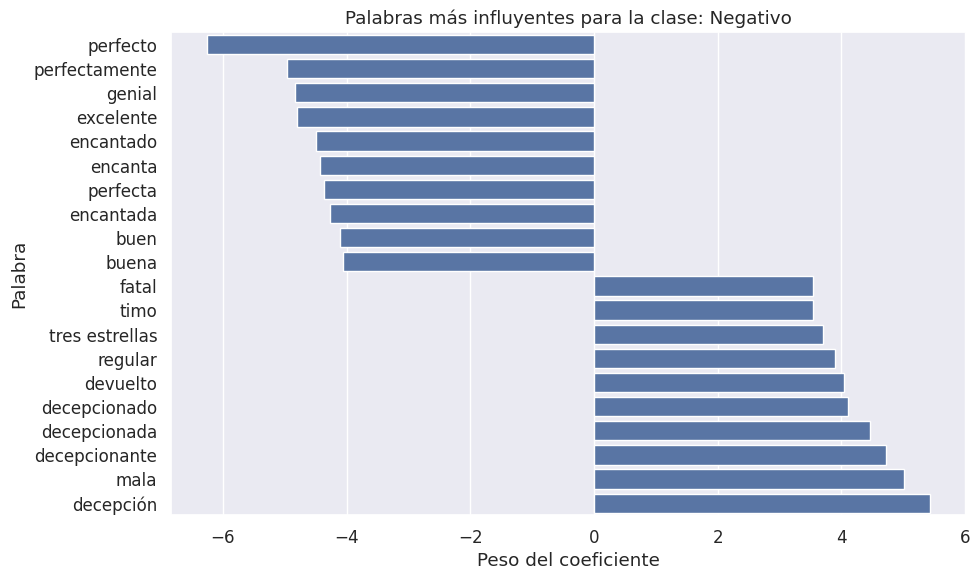

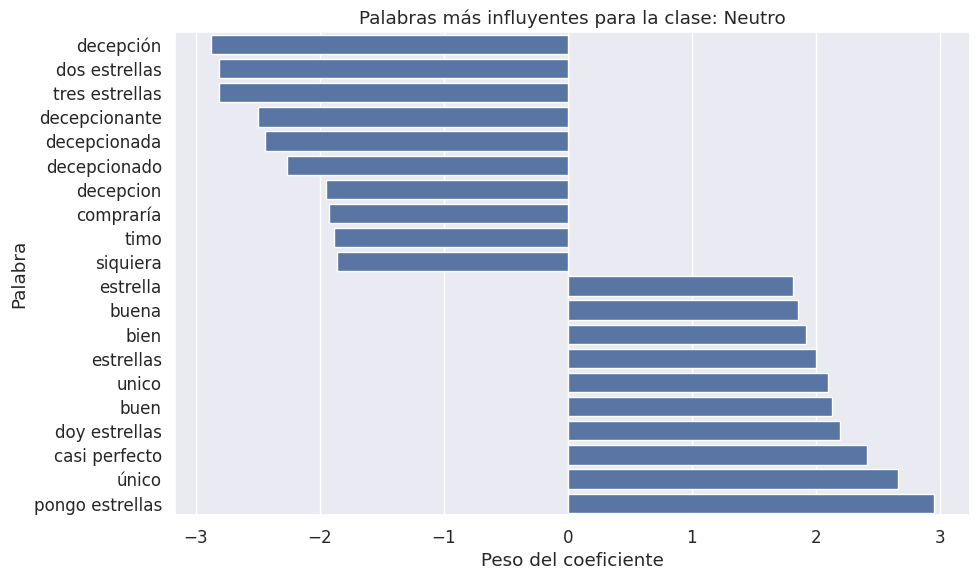

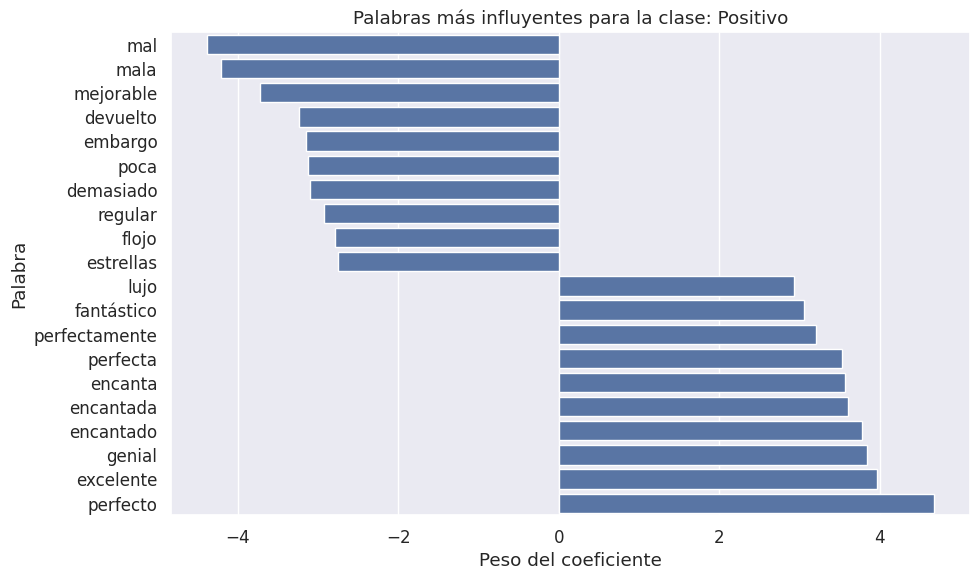

In [ ]:
for i, clase in enumerate(clases):
    top_pos, top_neg = top_palabras_por_clase(vectorizador, modelo, i)

    df_plot = pd.concat([top_pos, top_neg]).sort_values('coeficiente')

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=df_plot,
        x='coeficiente',
        y='palabra'
    )
    plt.title(f'Palabras más influyentes para la clase: {clase}')
    plt.xlabel('Peso del coeficiente')
    plt.ylabel('Palabra')
    plt.tight_layout()
    plt.show()


#### Análisis de Errores


In [ ]:
datos_test = X_test.to_frame(name='review').copy()
datos_test['real'] = y_test
datos_test['prediccion'] = y_pred

In [ ]:
errores = datos_test[datos_test['real'] != datos_test['prediccion']]
print(f"Total de errores: {len(errores)} de {len(datos_test)}")

Total de errores: 1380 de 5000


In [ ]:
errores.sample(10)

,review,real,prediccion
4917,carga doble e indicadores lcd buena duración y...,Positivo,Neutro
4694,buena compra me a gustado la comodidad lo aisl...,Positivo,Neutro
4663,para regalar pequeño pero muy bonito y suave,Positivo,Neutro
4811,buen producto todo correcto gracias,Positivo,Neutro
4718,me ha gustado mas de lo que me esperava recome...,Positivo,Neutro
1863,pocas semillas semillas aproximadamente pero b...,Negativo,Neutro
4678,buen producto pero no las veo efecto xenon bue...,Positivo,Neutro
1862,normal lo que se anuncia sin nada raro a mis g...,Negativo,Positivo
2558,me gusta la funda cumple perfectamente su func...,Negativo,Positivo
2976,no la entiendo para mi es complicada de usar n...,Negativo,Neutro


Errores de clasificación donde la clase real no coincide con la predicción. En un contexto multiclase, estos errores indican confusión entre sentimientos similares (por ejemplo, neutro vs positivo).

In [ ]:
for i, row in errores.head(10).iterrows():
    print(f"Review: {row['review'][:300]}...")
    print(f"Real: {row['real']} | Pred: {row['prediccion']}\n")

Review: hacen daño buena réplica son muy bonitas y muy conseguidas pero no son auténticas me dañan los pies y no es lo normal en esta marca...
Real: Negativo | Pred: Positivo

Review: luna se rompe fácilmente no recomendable para niños que no saben cuidar las cosas porque hay que cuidar que no se rompa...
Real: Negativo | Pred: Positivo

Review: lampara cuando las compre estaba muy contenta porque quedan bonitas pero al poco tiempo ya no funciona una de ellas si mucho uso no las volveria a comprar...
Real: Negativo | Pred: Positivo

Review: producto no recomendable instrucciones en inglés y muy difícil de colocar adecuadamente y si no lo haces perfectamente la pantalla pierde su tactibilidad...
Real: Negativo | Pred: Neutro

Review: perfectas para el postureo inservibles como gafas de sol si vas buscando unas gafas de sol que te protejan de los rayos uvno pierdas el tiempo éstas no son tus gafas ni protegen ni te dejan ver ya que los rayos solares reflejan en los cristales de las gafas

##### Ejemplos de errores más frecuentes entre clases

In [ ]:
errores_frecuentes = (
    errores
    .groupby(['real', 'prediccion'])
    .size()
    .reset_index(name='cantidad')
    .sort_values('cantidad', ascending=False)
)

display(errores_frecuentes.head(10))

,real,prediccion,cantidad
0,Negativo,Neutro,467
3,Neutro,Positivo,290
5,Positivo,Neutro,267
2,Neutro,Negativo,169
1,Negativo,Positivo,114
4,Positivo,Negativo,73


#### Matriz de confusión


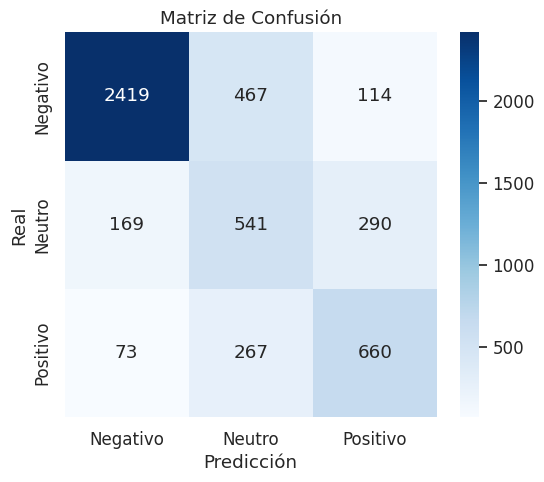

In [ ]:
plt.figure(figsize=(6, 5))
# Define the mapping from string labels to integer labels
label_mapping = {'Negativo': 0, 'Neutro': 1, 'Positivo': 2}

# Apply the mapping to y_test and y_pred
y_test_mapped = y_test.map(label_mapping)
y_pred_mapped = pd.Series(y_pred).map(label_mapping)

# Now create the confusion matrix using the mapped labels
cm = confusion_matrix(y_test_mapped, y_pred_mapped, labels=[0, 1, 2])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo','Neutro', 'Positivo'],
            yticklabels=['Negativo', 'Neutro', 'Positivo'])
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión')
plt.show()

## <font color=#05C0F3>**Serialización e Integración con Back-End (Java)**</font>

Esta es la fase de entrega del artefacto. El modelo entrenado y, crucialmente, el vectorizador TF-IDF (necesario para transformar el texto de entrada que envía el BE), deben ser guardados en un formato binario (joblib o pickle)

### **Definición del Pipeline de Predicción**

Para garantizar que el Back-End pueda hacer predicciones correctas, es mejor serializar el Pipeline completo: Vectorizador + Modelo.

In [ ]:
pipeline_final = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words=stopwords_es,
        ngram_range=(1, 2),
        max_features=5000,
        min_df=5,
        max_df=0.9
    )),
    ('clf', LogisticRegression(random_state=42))
])

### **Reentrenar el pipeline con X y Y**

In [ ]:
pipeline_final.fit(X, y)

### **Serialización**

In [ ]:
joblib.dump(pipeline_final, 'sentiment_model_1.2.joblib')

### **Contrato de Integración y Pruebas Locales**

Prueba en Python para simular la predicción, mostrando cómo el modelo toma un texto sin procesar y genera una predicción con probabilidad.

In [ ]:
# Simulación de predicción
texto_ejemplo = "La interfaz es confusa y me hicieron esperar mucho."

In [ ]:
pred_sentimiento = pipeline_final.predict([texto_ejemplo])

In [ ]:
probabilidades = pipeline_final.predict_proba([texto_ejemplo])

In [ ]:
# Sentimiento y su probabilidad asociada (máxima probabilidad)
max_proba = np.max(probabilidades)

In [ ]:
print(f"Predicción: {pred_sentimiento}, Probabilidad: {max_proba:.2f}")

#### **FastAPI**

**El siguiente codigo es de prueba y va en el archivo del proyecto en github**

~~~
# Instalaciones
# pip install fastapi uvicorn joblib scikit-learn nltk # Se ejecuta en consola

# app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import numpy as np

# Cargar el modelo (UNA SOLA VEZ)
app = FastAPI(title="Sentiment Analysis API")

modelo = joblib.load("sentiment_model_1.1.joblib")

# Contrato de entrada (request)
class SentimentRequest(BaseModel):
    text: str
#    {
#        text: "La película fue excelente"
#    }

# Contrato de salida (response)
class SentimentResponse(BaseModel):
    prevision: str
    probabilidad: float

# Endpoint principal /sentiment
@app.post("/sentiment", response_model=SentimentResponse)
def predict_sentiment(request: SentimentRequest):

    texto = request.text.strip()

    if len(texto) < 10:
        raise HTTPException(
            status_code=400,
            detail="El texto es demasiado corto para analizar sentimiento"
        )

    pred = modelo.predict([texto])[0]
    proba = modelo.predict_proba([texto])[0]

    probabilidad_max = float(np.max(proba))

    sentimiento = "Positivo" if pred == 1 else "Negativo"

    return {
        "prevision": sentimiento,
        "probabilidad": round(probabilidad_max, 3)
    }

# Ejecutar el servidor
# uvicorn app:app --reload # Se ejecuta en consola

POST http://localhost:8000/sentiment
Content-Type: application/json
# Eso va en:
# Postman
# Swagger
# README
# documentación

# Formato
{
  "text": "La interfaz es confusa y lenta"
}
{
  "prevision": "Negativo",
  "probabilidad": 0.92
}

~~~

**Comentario Fast API (Prueba)** **NO EJECUTAR**

**El archivo de Git tendría que tener esta estrucura**

- Modelo_hackathon.ipynb
- app.py
- requirements.txt
- sentiment_model.joblib

### Archivo requirements.txt
### Dentro del archivo .txt el siguiente texto:

- fastapi
- uvicorn
- joblib
- scikit-learn
- nltk
- numpy

**Cómo ejecutarlo (Terminal)**

**CMD, Terminal o PowerShell**

- 1. Instalar las librerías (solo la primera vez): pip install -r requirements.txt
- 2. Encender el servidor: uvicorn app:app --reload

### Arhivo ipynb, Modelo_hackathon.ipynb
El archivo .ipynb crea el archivo (sentiment_model.joblib)
Descargar el archivo .joblib y colocarlo dentro de la estructura del Git

**Cómo ejecutarlo (Terminal)**

**CMD, Terminal o PowerShell**

- 1. Instalar las librerías (solo la primera vez): `pip install -r requirements.txt`
- 2. Encender el servidor: `uvicorn app:app --reload`